<a href="https://colab.research.google.com/github/medipallysreeya-gif/Machine-learning-skill/blob/main/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Decision Tree Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.79      0.91      0.85       105
           1       0.84      0.65      0.73        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.80      0.80       179

Saved decision tree image.

Random Forest OOB score: 0.7921
Random Forest Test accuracy: 0.8101

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Feature importances:
 Fare: 0.2744
 Sex_male: 0.2713
 Age: 0.2488
 Pclass_3: 0.0670
 SibSp: 0.0483
 Parch: 0.0383
 Embarked_S: 0.0234
 Pclass_2: 0.0180
 Embarked_Q: 0.0105


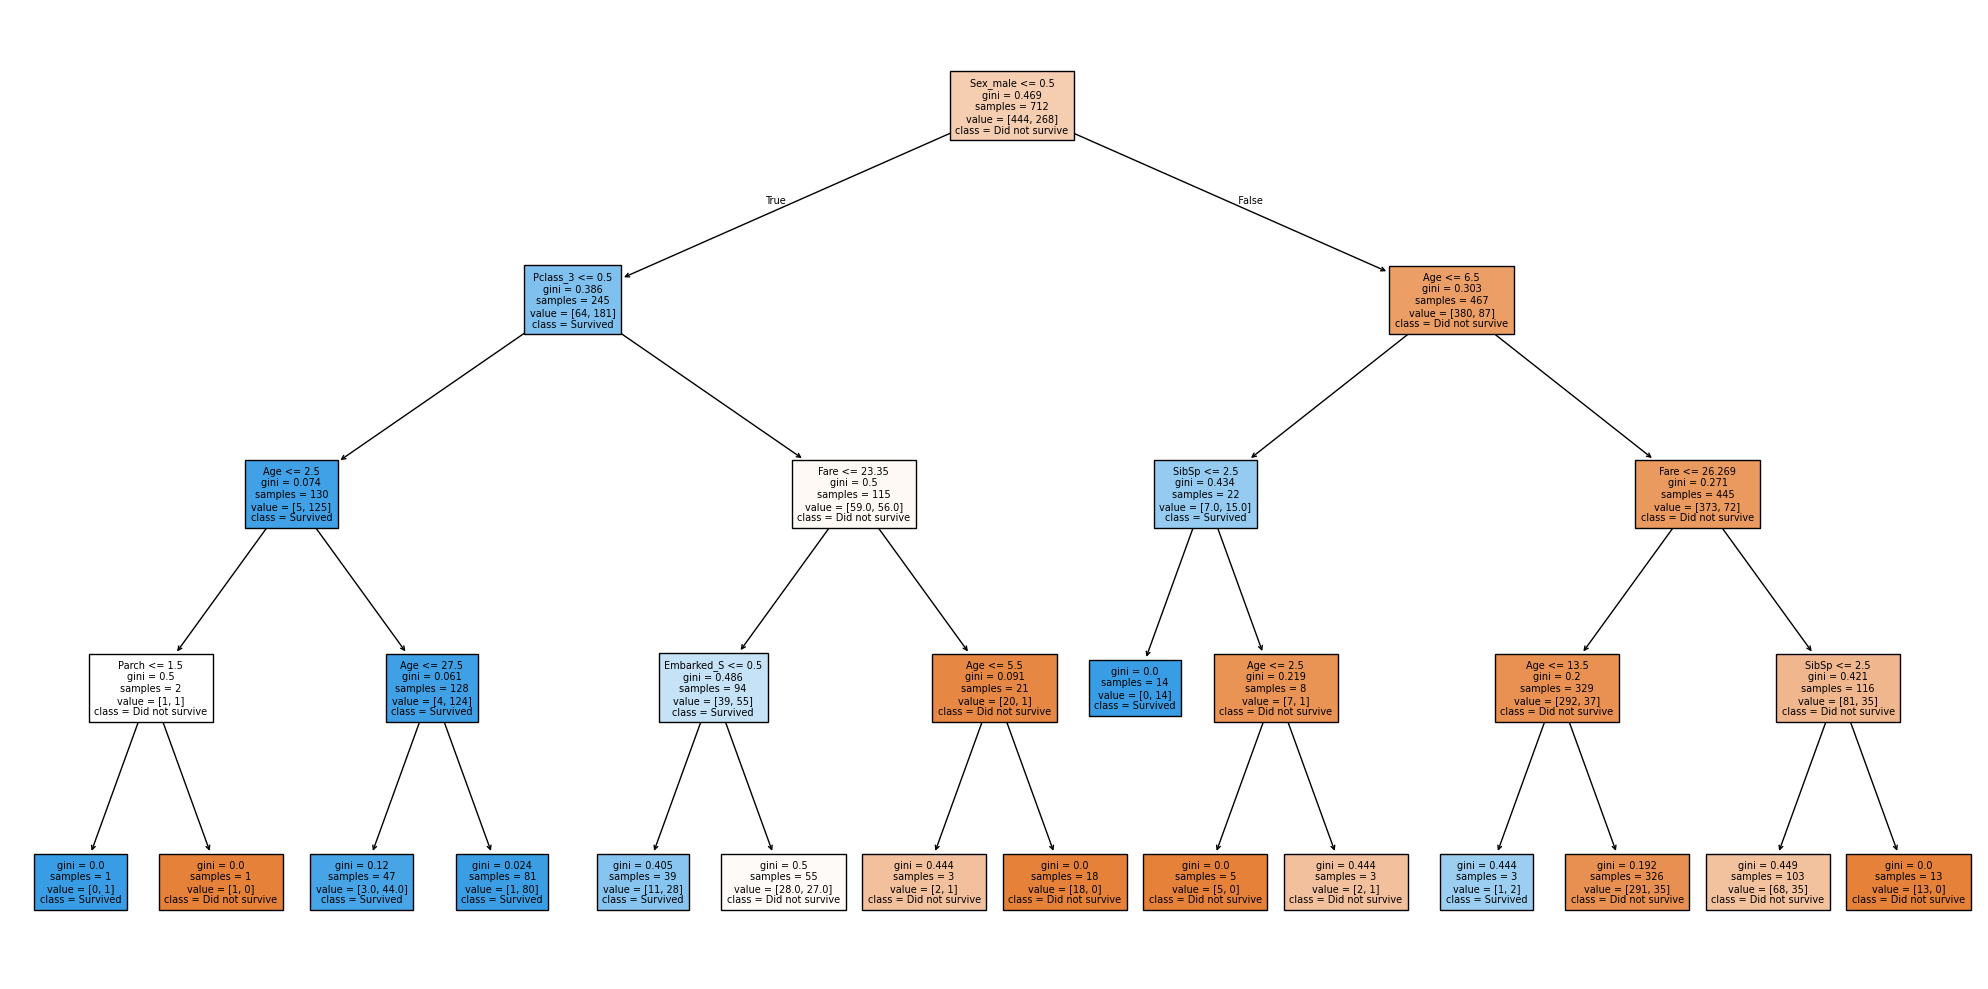

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# ---------------------------------------------------------
# 1. Load Titanic dataset
# ---------------------------------------------------------
df = pd.read_csv("Titanic-Dataset.csv")

# Drop irrelevant columns
drop_cols = ["PassengerId", "Name", "Ticket", "Cabin"]
df = df.drop(columns=drop_cols, errors="ignore")

# Fill missing values
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=["Sex", "Embarked", "Pclass"], drop_first=True)

# Features and target
X = df_encoded.drop(columns=["Survived"])
y = df_encoded["Survived"]

# ---------------------------------------------------------
# 2. Train/test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 3. Decision Tree Classifier
# ---------------------------------------------------------
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=["Did not survive", "Survived"], filled=True, fontsize=7)
plt.tight_layout()
plt.savefig("titanic_decision_tree.png", dpi=150)
print("Saved decision tree image.")

# ---------------------------------------------------------
# 4. Random Forest Classifier
# ---------------------------------------------------------
RANDOM_STATE = 42
rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)

# Evaluate
y_pred_rf = rf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"\nRandom Forest OOB score: {rf.oob_score_:.4f}")
print(f"Random Forest Test accuracy: {test_accuracy:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_rf))

# Feature importances
print("Feature importances:")
for name, importance in sorted(zip(X.columns, rf.feature_importances_), key=lambda x: -x[1]):
    print(f" {name}: {importance:.4f}")
